**Step 1. Show the first few lines of the csv to see if the csv file is successfully able to be read.**

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# absolute path 
df = pd.read_csv("/Users/evelyn/Documents/claudecode/speechlab/week-04/torgo_egemaps_summary.csv")
df.head() 

,name,frameTime,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,...,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp,label
0,'F01-Session1-wav_headMic-0116.wav',0.0,38.33156,0.109528,38.26910,39.06808,40.05841,1.789307,587.163300,866.361800,...,0.010385,0.057815,2.145046,2.363823,0.208696,0.159437,0.175600,0.167811,-25.17384,1
1,'MC03-Session1-wav_headMic-0586.wav',0.0,14.02498,0.154655,13.52956,13.53839,13.55250,0.022939,5.641339,3.890914,...,-0.003398,0.834803,1.234568,2.564103,0.355000,0.353589,0.023333,0.004714,-19.72760,0
2,'FC03-Session1-wav_headMic-0242.wav',0.0,32.16512,0.303630,13.59434,36.37801,38.03387,24.439530,193.087900,143.710900,...,-0.002278,0.339914,2.583026,3.773585,0.120000,0.098184,0.112727,0.104367,-16.56605,0
3,'MC01-Session2-wav_headMic-0268.wav',0.0,17.04129,0.346149,12.60095,13.40295,24.97907,12.378120,16.843840,13.457780,...,0.019647,0.035664,1.255230,2.991453,0.052857,0.039538,0.222500,0.208312,-39.51396,0
4,'MC02-Session1-wav_headMic-0068.wav',0.0,17.30344,0.233548,13.53755,16.78878,21.44546,7.907907,46.656320,76.326760,...,0.000590,0.405793,2.285714,2.312139,0.320000,0.253048,0.111000,0.040608,-16.57751,0


**Step 2. Check to see that the output is what I expected.**

I used openSMILE toolkit to extract eGeMAPS features, so I should expect to see 8000+ rows representing audio files, each with a set of 88 features.

Here are the checks I am performing: 
- df.shape — prints (rows, columns) to confirm 8,185 rows (we started off with 8,216 audio file inputs, but 31 of them failed to produce output) and 91 columns (88 eGeMAPS + name + frameTime)
- df["label"].value_counts() — counts how many dysarthric (1) vs control (0) files there are, so you can see if the dataset is balanced or imbalanced
- df.isnull().sum().sum() — counts any missing values across the whole dataframe (could happen if SMILExtract failed on some features)

In [70]:
print("Shape:", df.shape)
print("\nClass distribution:")
print(df["label"].value_counts())
print("\nMissing values:", df.isnull().sum().sum())

Shape: (8185, 91)

Class distribution:
label
0    5220
1    2965
Name: count, dtype: int64

Missing values: 0


**Step 3. Visualize feature distributions**

Plot histograms for the feature distributions of key features, split by whether the speaker has the control (0) or dysarthia (1) label. By looking for a clear separation between median and spread of the graph, this helps us determine if that feature is useful in distinguishing between the two groups.

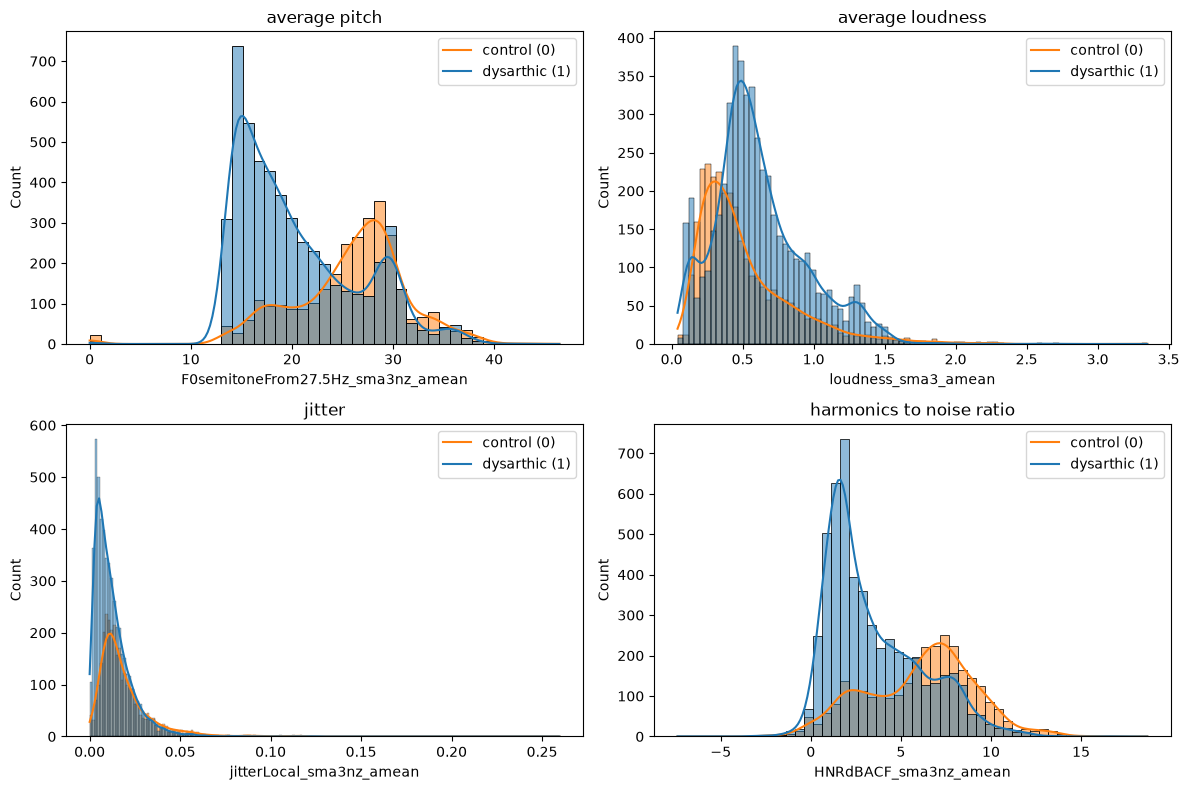

In [71]:
# dict for human understandable features
features_to_plot = {
    "F0semitoneFrom27.5Hz_sma3nz_amean": "average pitch",  
    "loudness_sma3_amean": "average loudness",                 
    "jitterLocal_sma3nz_amean": "jitter",             
    "HNRdBACF_sma3nz_amean" : "harmonics to noise ratio",              
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()



for i, (feature, description) in enumerate(features_to_plot.items()):
    sns.histplot(data=df, x=feature, hue="label", ax=axes[i], kde=True)
    axes[i].set_title(description)
    axes[i].legend(["control (0)", "dysarthic (1)"])

plt.tight_layout()
plt.show()

It's useful to analyze the graphs and see if it matches our human intuition and knowledge about the disease. In general, speakers with dysarthia show these patterns: their voice is "less smooth/steady" and sounds rough or hoarse, less control.

Here is a comparison of what we expect to see and what shows up on the graph. 
- Pitch (F0) — dysarthric speakers often have more monotone or irregular pitch, so the average pitch should be lower -> the median of the blue graph is lower!
- Loudness — dysarthric speech can be quieter or more variable -> the dysarthia speakers actually have a louder volume and similar variance
- Jitter — expect dysarthric speakers to have higher jitter (more irregular vocal fold vibration due to motor control issues) -> not much of a difference
- HNR — expect dysarthric speakers to have lower HNR (noisier, less periodic voice) -> yes, this is pretty clearly reflected! the blue graph is to the left

Interpretation: The histogram for average pitch shows a clear separation between dysarthric speakers and control speakers, with dysarthric speakers tending to have a lower pitch. However, this feature is not necessarily a reliable vocal biomarker; clinical studies suggest that while dysarthria reduces pitch variability, it can’t predict the directional shift of the pitch [17]. Next, the histograms for loudness and jitter did not support my hypothesis. Clinical studies indicate that dysarthric speakers have reduced loudness due to insufficient subglottic air pressure [18]; however, the graph shows the median for average loudness to be higher in dysarthric patients. Furthermore, there is evidence that dysarthric speakers have higher jitter due to poor control over laryngeal muscles, but the histograms show little difference between the two groups [19]. The final histogram did confirm my hypothesis: dysarthric speakers typically have a lower harmonics-to-noise ratio since their vocal folds do not vibrate evenly and produce as many harmonics. [20]


**Step 4. PCA — visualize separation between groups in 2D**

PCA (Principal Component Analysis) compresses all 88 eGeMAPS features down into 2 numbers per file, called PC1 and PC2. These two numbers capture the directions of maximum variance across the whole dataset. Optimally, I would expect their points to form two separate clusters, one for dysarthric and one for the control group. 

Color code: dysarthic-red, control-blue

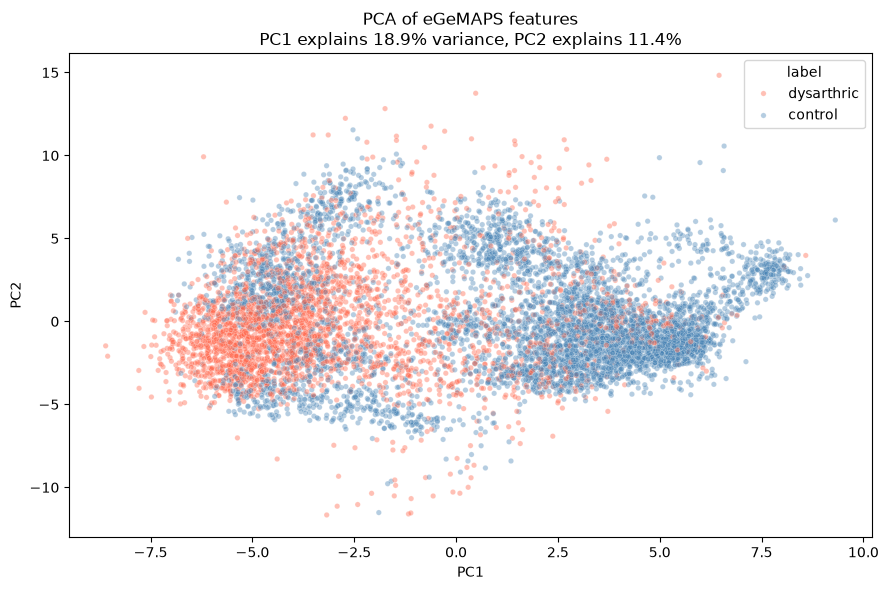

In [72]:
feature_cols = [c for c in df.columns if c not in ("name", "frameTime", "label")]

# scale features to zero mean and unit variance before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])

# reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# add PCA coords to a plotting dataframe
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "label": df["label"].map({0: "control", 1: "dysarthric"}),
})

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=pca_df, x="PC1", y="PC2",
    hue="label", alpha=0.4, s=15,
    palette={"control": "steelblue", "dysarthric": "tomato"},
    ax=ax,
)
ax.set_title(
    f"PCA of eGeMAPS features\n"
    f"PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% variance, "
    f"PC2 explains {pca.explained_variance_ratio_[1]*100:.1f}%"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

**PCA for visualization vs. PCA for model training**

The PCA above uses `n_components=2` purely so we can plot it — humans can only read 2D scatter plots. But squashing 88 features into 2 numbers throws away most of the information, which is fine for eyeballing but bad for a classifier.

When people use PCA *before* training a model, the goal is different: keep enough components to retain ~95% of the variance (often 20–50 components for a dataset this size) while removing noise and redundant features. The tradeoff is:

| | Visualization PCA (2D) | Pre-training PCA (e.g. 30–50 components) |
|---|---|---|
| **Goal** | See rough group separation | Feed compact, decorrelated features to a model |
| **Components** | 2–3 | Enough to hit ~95% explained variance |
| **Info retained** | Low (~30–50%) | High (~95%) |
| **Output** | A scatter plot | A transformed feature matrix to pass to a classifier |


For this project, using all 88 raw eGeMAPS features is reasonable — 88 features and 8,000 samples is not a big matrix, so there's no need for PCA dimentionality reduction before training  -> we can feed the full feature set to the classifier in the next step.

Feature engineering would matter if you were starting from raw audio waveforms or spectrograms which have a LOT more data encoded in them — since I'm starting from a set of eGeMAPS info, the features are already meaningful and interpretable.

**Step 5. Random Forest classifier + feature importances**

A Random Forest trains many decision trees on random subsets of the data and features, then majority-votes their predictions. It naturally ranks features by how much each one reduced prediction error across all trees — this is called **feature importance**. Features that appear near the top of that ranking are the most useful acoustic cues for distinguishing dysarthric from control speech.

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

X = df[feature_cols].values
y = df["label"].values

# stratified split keeps the class ratio the same in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# class_weight="balanced" compensates for 5220 control vs 2965 dysarthric
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print(classification_report(y_test, rf.predict(X_test), target_names=["control", "dysarthric"]))

              precision    recall  f1-score   support

     control       0.99      0.99      0.99      1044
  dysarthric       0.99      0.99      0.99       593

    accuracy                           0.99      1637
   macro avg       0.99      0.99      0.99      1637
weighted avg       0.99      0.99      0.99      1637



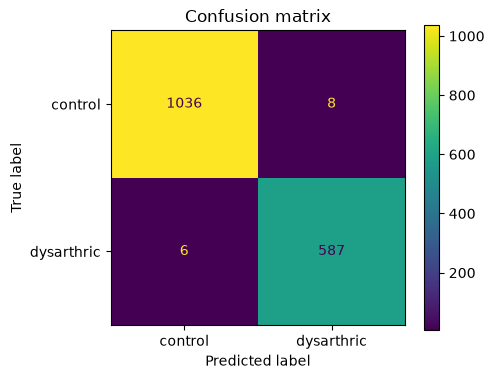

In [74]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf.predict(X_test),
    display_labels=["control", "dysarthric"],
    ax=ax,
)
ax.set_title("Confusion matrix")
plt.tight_layout()
plt.show()

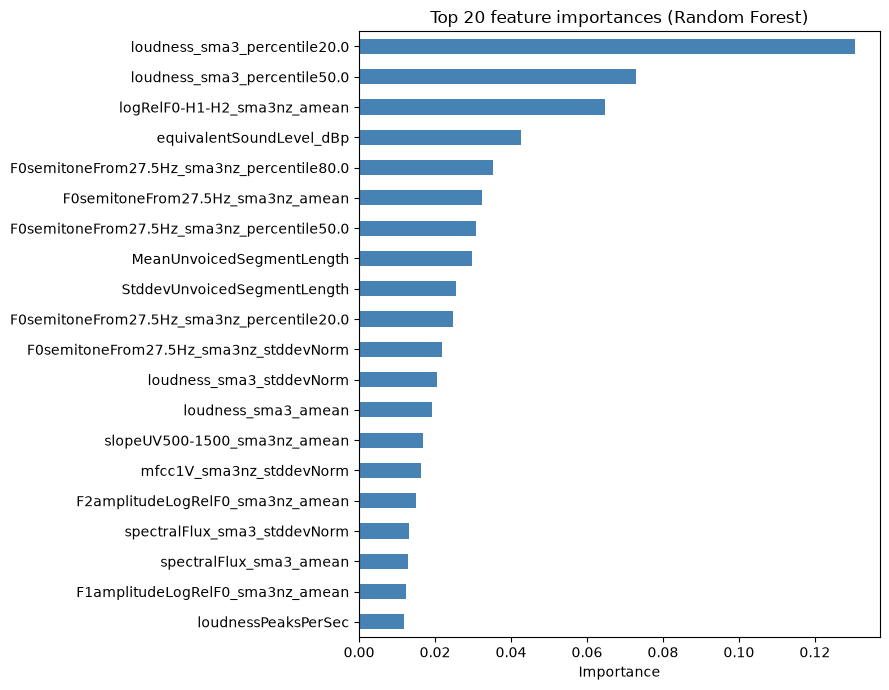

In [75]:
# plot top 20 most important features
importances = pd.Series(rf.feature_importances_, index=feature_cols)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
top20.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 20 feature importances (Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

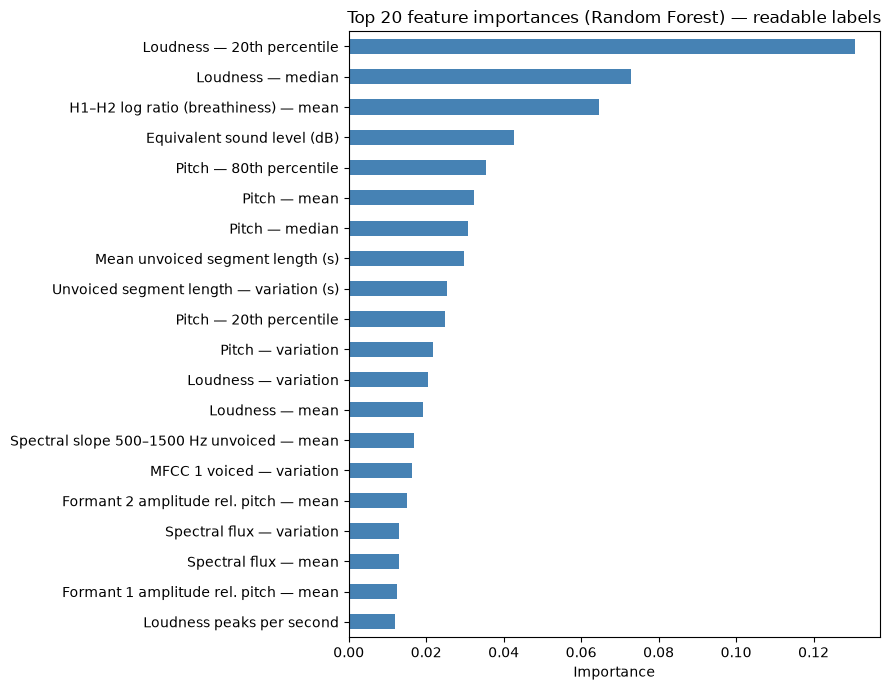

In [76]:
# human-readable names for all 88 eGeMAPS features
readable = {
    # Pitch (F0)
    "F0semitoneFrom27.5Hz_sma3nz_amean":            "Pitch — mean",
    "F0semitoneFrom27.5Hz_sma3nz_stddevNorm":       "Pitch — variation",
    "F0semitoneFrom27.5Hz_sma3nz_percentile20.0":   "Pitch — 20th percentile",
    "F0semitoneFrom27.5Hz_sma3nz_percentile50.0":   "Pitch — median",
    "F0semitoneFrom27.5Hz_sma3nz_percentile80.0":   "Pitch — 80th percentile",
    "F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2":     "Pitch — range (20th–80th)",
    "F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope":  "Pitch — rising slope (mean)",
    "F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope":"Pitch — rising slope (variation)",
    "F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope": "Pitch — falling slope (mean)",
    "F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope":"Pitch — falling slope (variation)",
    # Jitter (cycle-to-cycle pitch irregularity)
    "jitterLocal_sma3nz_amean":                     "Jitter — mean",
    "jitterLocal_sma3nz_stddevNorm":                "Jitter — variation",
    # Shimmer (cycle-to-cycle amplitude irregularity)
    "shimmerLocaldB_sma3nz_amean":                  "Shimmer — mean",
    "shimmerLocaldB_sma3nz_stddevNorm":             "Shimmer — variation",
    # Harmonics-to-Noise Ratio
    "HNRdBACF_sma3nz_amean":                        "HNR — mean",
    "HNRdBACF_sma3nz_stddevNorm":                   "HNR — variation",
    # H1-H2 log ratio (breathiness — incomplete glottal closure)
    "logRelF0-H1-H2_sma3nz_amean":                 "H1–H2 log ratio (breathiness) — mean",
    "logRelF0-H1-H2_sma3nz_stddevNorm":            "H1–H2 log ratio (breathiness) — variation",
    # H1-A3 log ratio (voice quality — strength of 3rd formant relative to H1)
    "logRelF0-H1-A3_sma3nz_amean":                 "H1–A3 log ratio (voice quality) — mean",
    "logRelF0-H1-A3_sma3nz_stddevNorm":            "H1–A3 log ratio (voice quality) — variation",
    # Loudness
    "loudness_sma3_amean":                          "Loudness — mean",
    "loudness_sma3_stddevNorm":                     "Loudness — variation",
    "loudness_sma3_percentile20.0":                 "Loudness — 20th percentile",
    "loudness_sma3_percentile50.0":                 "Loudness — median",
    "loudness_sma3_percentile80.0":                 "Loudness — 80th percentile",
    "loudness_sma3_pctlrange0-2":                   "Loudness — range (20th–80th)",
    "loudness_sma3_meanRisingSlope":                "Loudness — rising slope (mean)",
    "loudness_sma3_stddevRisingSlope":              "Loudness — rising slope (variation)",
    "loudness_sma3_meanFallingSlope":               "Loudness — falling slope (mean)",
    "loudness_sma3_stddevFallingSlope":             "Loudness — falling slope (variation)",
    # MFCCs (vocal tract shape) — all frames and voiced-only
    "mfcc1_sma3_amean":                             "MFCC 1 — mean",
    "mfcc1_sma3_stddevNorm":                        "MFCC 1 — variation",
    "mfcc2_sma3_amean":                             "MFCC 2 — mean",
    "mfcc2_sma3_stddevNorm":                        "MFCC 2 — variation",
    "mfcc3_sma3_amean":                             "MFCC 3 — mean",
    "mfcc3_sma3_stddevNorm":                        "MFCC 3 — variation",
    "mfcc4_sma3_amean":                             "MFCC 4 — mean",
    "mfcc4_sma3_stddevNorm":                        "MFCC 4 — variation",
    "mfcc1V_sma3nz_amean":                          "MFCC 1 voiced — mean",
    "mfcc1V_sma3nz_stddevNorm":                     "MFCC 1 voiced — variation",
    "mfcc2V_sma3nz_amean":                          "MFCC 2 voiced — mean",
    "mfcc2V_sma3nz_stddevNorm":                     "MFCC 2 voiced — variation",
    "mfcc3V_sma3nz_amean":                          "MFCC 3 voiced — mean",
    "mfcc3V_sma3nz_stddevNorm":                     "MFCC 3 voiced — variation",
    "mfcc4V_sma3nz_amean":                          "MFCC 4 voiced — mean",
    "mfcc4V_sma3nz_stddevNorm":                     "MFCC 4 voiced — variation",
    # Formants (resonance frequencies of the vocal tract)
    "F1frequency_sma3nz_amean":                     "Formant 1 freq — mean",
    "F1frequency_sma3nz_stddevNorm":                "Formant 1 freq — variation",
    "F1bandwidth_sma3nz_amean":                     "Formant 1 bandwidth — mean",
    "F1bandwidth_sma3nz_stddevNorm":                "Formant 1 bandwidth — variation",
    "F1amplitudeLogRelF0_sma3nz_amean":             "Formant 1 amplitude rel. pitch — mean",
    "F1amplitudeLogRelF0_sma3nz_stddevNorm":        "Formant 1 amplitude rel. pitch — variation",
    "F2frequency_sma3nz_amean":                     "Formant 2 freq — mean",
    "F2frequency_sma3nz_stddevNorm":                "Formant 2 freq — variation",
    "F2bandwidth_sma3nz_amean":                     "Formant 2 bandwidth — mean",
    "F2bandwidth_sma3nz_stddevNorm":                "Formant 2 bandwidth — variation",
    "F2amplitudeLogRelF0_sma3nz_amean":             "Formant 2 amplitude rel. pitch — mean",
    "F2amplitudeLogRelF0_sma3nz_stddevNorm":        "Formant 2 amplitude rel. pitch — variation",
    "F3frequency_sma3nz_amean":                     "Formant 3 freq — mean",
    "F3frequency_sma3nz_stddevNorm":                "Formant 3 freq — variation",
    "F3bandwidth_sma3nz_amean":                     "Formant 3 bandwidth — mean",
    "F3bandwidth_sma3nz_stddevNorm":                "Formant 3 bandwidth — variation",
    "F3amplitudeLogRelF0_sma3nz_amean":             "Formant 3 amplitude rel. pitch — mean",
    "F3amplitudeLogRelF0_sma3nz_stddevNorm":        "Formant 3 amplitude rel. pitch — variation",
    # Spectral shape — voiced segments
    "alphaRatioV_sma3nz_amean":                     "Alpha ratio voiced — mean",
    "alphaRatioV_sma3nz_stddevNorm":                "Alpha ratio voiced — variation",
    "hammarbergIndexV_sma3nz_amean":                "Hammarberg index voiced — mean",
    "hammarbergIndexV_sma3nz_stddevNorm":           "Hammarberg index voiced — variation",
    "slopeV0-500_sma3nz_amean":                     "Spectral slope 0–500 Hz voiced — mean",
    "slopeV0-500_sma3nz_stddevNorm":                "Spectral slope 0–500 Hz voiced — variation",
    "slopeV500-1500_sma3nz_amean":                  "Spectral slope 500–1500 Hz voiced — mean",
    "slopeV500-1500_sma3nz_stddevNorm":             "Spectral slope 500–1500 Hz voiced — variation",
    "spectralFluxV_sma3nz_amean":                   "Spectral flux voiced — mean",
    "spectralFluxV_sma3nz_stddevNorm":              "Spectral flux voiced — variation",
    # Spectral shape — all frames
    "spectralFlux_sma3_amean":                      "Spectral flux — mean",
    "spectralFlux_sma3_stddevNorm":                 "Spectral flux — variation",
    # Spectral shape — unvoiced segments
    "alphaRatioUV_sma3nz_amean":                    "Alpha ratio unvoiced — mean",
    "hammarbergIndexUV_sma3nz_amean":               "Hammarberg index unvoiced — mean",
    "slopeUV0-500_sma3nz_amean":                    "Spectral slope 0–500 Hz unvoiced — mean",
    "slopeUV500-1500_sma3nz_amean":                 "Spectral slope 500–1500 Hz unvoiced — mean",
    "spectralFluxUV_sma3nz_amean":                  "Spectral flux unvoiced — mean",
    # High-level descriptors
    "loudnessPeaksPerSec":                          "Loudness peaks per second",
    "VoicedSegmentsPerSec":                         "Voiced segments per second",
    "MeanVoicedSegmentLengthSec":                   "Mean voiced segment length (s)",
    "StddevVoicedSegmentLengthSec":                 "Voiced segment length — variation (s)",
    "MeanUnvoicedSegmentLength":                    "Mean unvoiced segment length (s)",
    "StddevUnvoicedSegmentLength":                  "Unvoiced segment length — variation (s)",
    "equivalentSoundLevel_dBp":                     "Equivalent sound level (dB)",
}

# remap top20 index to readable labels; fall back to raw name if not in dict
top20_readable = top20.copy()
top20_readable.index = [readable.get(f, f) for f in top20.index]

fig, ax = plt.subplots(figsize=(9, 7))
top20_readable.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 20 feature importances (Random Forest) — readable labels")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

**Analysis: what do the top features tell us?**

The feature importance ranking aligns well with the clinical understanding of dysarthria:

**1. Loudness dominates (features 1, 2, 4, 12, 13, 20)**
Loudness — 20th percentile is the single most important feature by a large margin, with Loudness — median close behind. The 20th percentile specifically captures the *quietest moments* in an utterance — the floor of the loudness range. Dysarthric speakers often have reduced breath support and weaker vocal intensity, so their quiet moments are especially quiet. Equivalent sound level (dB), Loudness — mean, Loudness — variation, and Loudness peaks per second all appear elsewhere in the top 20, confirming that loudness is the most discriminative acoustic dimension overall.

**2. H1–H2 log ratio (breathiness) — 3rd most important**
This feature measures the relative energy of the first harmonic (H1) vs the second harmonic (H2) in the voice. A higher H1-H2 ratio indicates breathier phonation, associated with incomplete glottal closure. This is a classic voice quality marker — its high ranking suggests that how dysarthric speakers *produce* their voice (phonation quality) is a strong signal, not just how loud or high-pitched they are.

**3. Pitch features cluster in the middle (features 5–11)**
Pitch — 80th percentile, mean, median, 20th percentile, and variation all appear. Together, these describe the pitch level and how much the speaker varies their pitch. Dysarthric speakers often speak in a narrower pitch range (more monotone) or at atypical pitch levels due to impaired laryngeal motor control.

**4. Pause/silence patterns (features 8–9)**
Mean unvoiced segment length and its variation both rank in the top 10. These capture the length and consistency of pauses between words. Dysarthric speakers tend to have longer and more irregular pauses due to slower speaking rate and impaired motor planning — this is one of the most perceptually salient signs of dysarthria.

**5. Formant amplitudes at the bottom (features 16, 19)**
Formant 1 and 2 amplitudes relative to pitch appear near the bottom of the top 20. Formant amplitudes reflect how strongly the vocal tract resonances are excited — changes here are consistent with imprecise vowel articulation (a known dysarthria symptom), though they contribute less than loudness and pitch overall.

**Step 6. Speaker-held-out split — fixing the leakage problem**

The 99% accuracy from step 5 may be misleading. The issue is **speaker leakage**: the random 80/20 split scattered utterances from the same speaker across both train and test. So when the model sees a test utterance from MC01, it already learned MC01's voice from hundreds of training utterances — it's recognizing the *speaker*, not *dysarthria*.

A proper evaluation holds out speakers entirely: train on some speakers, test on completely different ones. This forces the model to generalize to new voices it has never heard, which is what a real clinical tool would need to do.

**Split:**
- Test speakers: F03, M02 (dysarthric) + FC03, MC02 (control)
- Train speakers: all remaining 11 speakers

In [78]:
import numpy as np

# extract speaker ID from filename (e.g. 'F03-Session1-...' -> 'F03')
df["speaker"] = df["name"].str.strip("'").str.split("-").str[0]

test_speakers = {"F03", "M02", "FC03", "MC02"}
train_mask = ~df["speaker"].isin(test_speakers)
test_mask  =  df["speaker"].isin(test_speakers)

X_train_spk = df.loc[train_mask, feature_cols].values
y_train_spk = df.loc[train_mask, "label"].values
X_test_spk  = df.loc[test_mask,  feature_cols].values
y_test_spk  = df.loc[test_mask,  "label"].values

print("Train:", X_train_spk.shape, "| class counts:", dict(zip(*np.unique(y_train_spk, return_counts=True))))
print("Test: ", X_test_spk.shape,  "| class counts:", dict(zip(*np.unique(y_test_spk,  return_counts=True))))

Train: (5733, 88) | class counts: {np.int64(0): np.int64(3754), np.int64(1): np.int64(1979)}
Test:  (2452, 88) | class counts: {np.int64(0): np.int64(1466), np.int64(1): np.int64(986)}


Speaker-held-out results:
              precision    recall  f1-score   support

     control       0.79      0.75      0.77      1466
  dysarthric       0.66      0.71      0.68       986

    accuracy                           0.73      2452
   macro avg       0.72      0.73      0.73      2452
weighted avg       0.74      0.73      0.73      2452



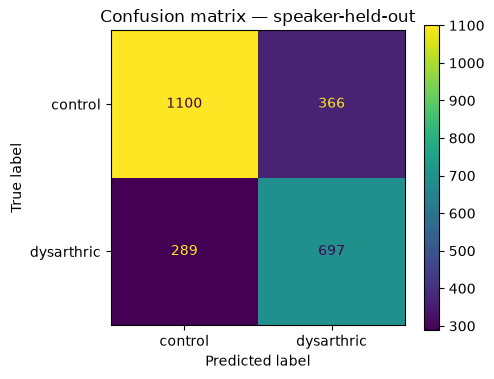

In [79]:
import numpy as np

rf_spk = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)
rf_spk.fit(X_train_spk, y_train_spk)

print("Speaker-held-out results:")
print(classification_report(y_test_spk, rf_spk.predict(X_test_spk), target_names=["control", "dysarthric"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test_spk, rf_spk.predict(X_test_spk),
    display_labels=["control", "dysarthric"],
    ax=ax,
)
ax.set_title("Confusion matrix — speaker-held-out")
plt.tight_layout()
plt.show()

**Step 7. SHAP — direction and per-prediction explanations**

Random Forest feature importances tell you which features mattered *on average*, but not the *direction* (does higher loudness push toward dysarthric or control?) or why any individual utterance was classified the way it was.

SHAP (SHapley Additive exPlanations) fixes both. For each prediction it assigns every feature a SHAP value: positive = pushed toward dysarthric, negative = pushed toward control. The beeswarm plot below shows all test predictions at once — each dot is one utterance, color shows the feature value (red = high, blue = low), and the x-axis shows the direction and magnitude of its effect on the prediction.

How to read the beeswarm:

- Top features = most impactful (same ranking as importances)
- Red dots far right = high feature value strongly predicts dysarthric
- Blue dots far right = low feature value strongly predicts dysarthric
- Dots near zero = that feature had little effect on that prediction

For example, if loudness — 20th percentile shows blue dots on the right, it means low loudness floor → dysarthric, which is exactly what we'd expect clinically.

In [ ]:
import sys
print(sys.executable)
import numpy; print(numpy.__version__)
! pip show numpy
! pip install "numpy==2.4.6" --force-reinstall --no-deps
! pip show numpy

import shap

readable_names = [readable.get(f, f) for f in feature_cols]

explainer = shap.TreeExplainer(rf)
# compute SHAP values for the test set (class 1 = dysarthric)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(
    shap_values[:, :, 1],   # class 1 (dysarthric)
    X_test,
    feature_names=readable_names,
    max_display=20,
    show=True,
)



/Users/evelyn/Documents/claudecode/speechlab/summeratseas/bin/python
2.5.0
Name: numpy
Version: 2.4.6
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License-Expression: BSD-3-Clause AND 0BSD AND MIT AND Zlib AND CC0-1.0
Location: /Users/evelyn/Documents/claudecode/speechlab/summeratseas/lib/python3.14/site-packages
Requires: 
Required-by: contourpy, matplotlib, numba, pandas, scikit-learn, scipy, seaborn, shap
  Using cached numpy-2.4.6-cp314-cp314-macosx_11_0_arm64.whl.metadata (6.6 kB)
Using cached numpy-2.4.6-cp314-cp314-macosx_11_0_arm64.whl (14.7 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6
Name: numpy
Version: 2.4.6
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License-Expression: BSD-3-Clause AND

ImportError: Numba needs NumPy 2.4 or less. Got NumPy 2.5.

ImportError: Numba needs NumPy 2.4 or less. Got NumPy 2.5.